In [2]:
import pandas as pd

In [10]:
# files хэсэг документыг хуулсан

df = pd.read_csv('exam_scores.csv')

# drive-тай холбохыг хүсвэл доорх зарчмаар

# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/My Drive/[your_path]/[file_name].csv')

In [11]:
# багана мөр

df.shape

(630000, 13)

# Өгөгдөл засах, цэвэрлэх

In [12]:
# exploring the dataset

df.describe(include='object')

,gender,course,internet_access,sleep_quality,study_method,facility_rating,exam_difficulty
count,367614,614318,614369,614120,614054,614076,614239
unique,17,7,2,9,10,7,3
top,male,b.tech,yes,poor,coaching,medium,moderate
freq,120185,127996,565047,206177,127087,206644,345105


In [13]:
# age missing   ok
# study_hours missing     ok
# class_attendance missing
# sleep_hours missing
# exam_score missing

# course, internet, sleep_quality, study_method, facility_rating, exam_difficulty missing
# category datag negen jigd bolgoh, zasah



## Өгөгдөл засах ерөнхий шат дараалал
1. Хэрэгцээтэй бүх багана, мөр орж ирсэн эсэхийг шалгах
2. Өгөгдлийн төрлийг нягтлах
3. Давхардлыг шалгах

## Тоон өгөгдөл засах

1. Тойм статистикаар үнэлэх
2. Өгөгдлийн хэдэн хувь дутуу байгааг тооцох (хэрэгцээт баганы өгөгдөл 5%-с дээш хоосон байвал асуудалтай)
3. Histogram эсвэл boxplot-оор дүрсэлж харах
4. Боломжтой бол бизнес мэдлэгтэй хүн эсвэл тухайн салбарын хүнээс лавлаж асуух
5. Хэт хазайсан (outlier) утгыг домэйн мэдлэг ашиглан засах эсвэл статистик тест (IQR) ашиглан
    - хасах (None утгатай болгох)
    - засах (Статистикт тохирох min, max утгаар солих)
    - бүтэн мөрөөр нь устгах
6. Тойм статистикийг дахин тооцоолох, дахин дүрсэлж харах
7. Хоосон утгыг нөхөхдөө (зарим тохиолдолд шууд хасаж болно)
    - Салбарын мэдлэг ашиглах
    - Медиан эсвэл дундаж утгаар орлуулах
    - [Интерполяци](https://medium.com/@amit25173/understanding-pandas-interpolate-d2868934633b) эсвэл экстраполяцийн арга
    - Машин сургалтын техник ашиглаж нөхөх

**WARNING**

- Дундаж утгаар шууд нөхөх нь тархалтыг гажуудуулж болно
- Outlier болгоныг устгах шаардлага байдаггүй

In [15]:
df.iloc[2:7]

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
2,2,20.0,NaN,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,75.0
3,3,19.0,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,60.0
4,4,23.0,male,bca,7.65,86.9,yes,9.6,good,self-study,NaN,easy,87.0
5,5,24.0,NaN,b.com,5.04,85.1,yes,9.4,average,online videos,medium,moderate,73.0
6,6,20.0,NaN,b.sc,4.28,87.0,no,9.1,average,mixed,high,moderate,78.0


In [16]:
df.loc[0:3, 'sleep_quality']

,sleep_quality
0,average
1,poor
2,poor
3,average


In [17]:
# df[df['sleep_hours'] > 5]

df.loc[df['sleep_hours'].isna(), ['sleep_hours', 'sleep_quality']]

,sleep_hours,sleep_quality
28,NaN,average
196,NaN,average
256,NaN,average
314,NaN,good
363,NaN,poor
...,...,...
629847,NaN,average
629866,NaN,good
629970,NaN,good
629976,NaN,average


<Axes: >

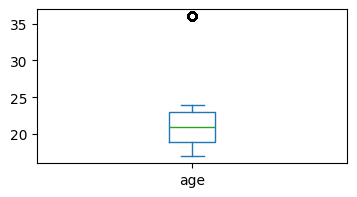

In [18]:
df['age'].plot(kind='box', figsize=(4, 2))

In [19]:
# .count(), .min(), .max(), .mean(), .quantile(0.25), .std(), .median()

In [20]:
# function(df['age']) гэж series өгч байгаа болохоор .series.quantile гэнэ
# df['age'].apply(function) байсан бол шууд тоон дээр үйлдэл хийж явна

def find_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    statistic_min = q1 - 1.5 * iqr
    statistic_max = q3 + 1.5 * iqr
    return statistic_min, statistic_max

In [21]:
age_min, age_max = find_iqr(df['age'])

In [22]:
print('Өгөгдөл дээрх максимум', df['age'].max())
print('Өгөгдөл дээр суурилсан тархалтын хувьд максимум', age_max)

Өгөгдөл дээрх максимум 36.0
Өгөгдөл дээр суурилсан тархалтын хувьд максимум 29.0


In [24]:
# Outlier насыг хоосон болгоё

df.loc[df['age'] > age_max, 'age'] = None

In [27]:
# null bish rate ---> 96.5%

print(df['age'].count() / df.shape[0] * 100)

## OR ##

print(f"Хоосон утгын хувь {round(df['age'].isna().sum() / df.shape[0] * 100, 2)}%")

96.5520634920635
Хоосон утгын хувь 3.45%


In [28]:
# age нь хоосон буюу утгагүй үед 'age'-н утгыг медианаар нөхөх

df.loc[df['age'].isna(), 'age'] = df['age'].median()

### OR ####

age_median = df['age'].median()
df.loc[df['age'].isna(), 'age'] = age_median

Насны тоо 630000


<Axes: ylabel='Frequency'>

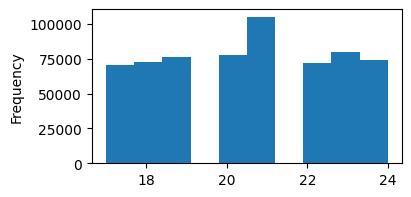

In [31]:
print('Насны тоо', df['age'].count() )
df['age'].plot(kind='hist', figsize=(4, 2))

### Дараагийн feature

<Axes: ylabel='Frequency'>

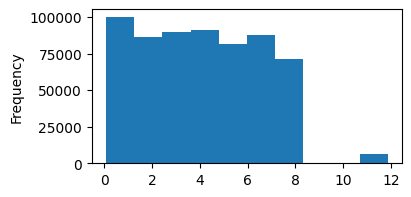

In [33]:
df['study_hours'].plot(kind='hist', figsize=(4, 2))

In [37]:
print(df[df['study_hours'] > 10]['study_hours'].count())

study_hours_min, study_hours_max = find_iqr(df['sleep_hours'])
print("Дата минимум", df['study_hours'].min(), "Статистик минимум", study_hours_min)
print("Дата максимум", df['study_hours'].max(), "Статистик максимум", study_hours_max)

6256
Дата минимум 0.08 Статистик минимум 1.0999999999999996
Дата максимум 11.865 Статистик максимум 13.1


In [39]:
# Статистик хувьд outlier байхгүй
df.loc[df['study_hours'].isna(), 'study_hours'] = df['study_hours'].median()

print(df['study_hours'].count())

630000


In [58]:
df.loc[df['sleep_hours'].isna(), 'sleep_hours'] = df['sleep_hours'].median()
df.loc[df['class_attendance'].isna(), 'class_attendance'] = df['class_attendance'].median()
df.loc[df['exam_score'].isna(), 'exam_score'] = df['exam_score'].median()

<Axes: ylabel='Frequency'>

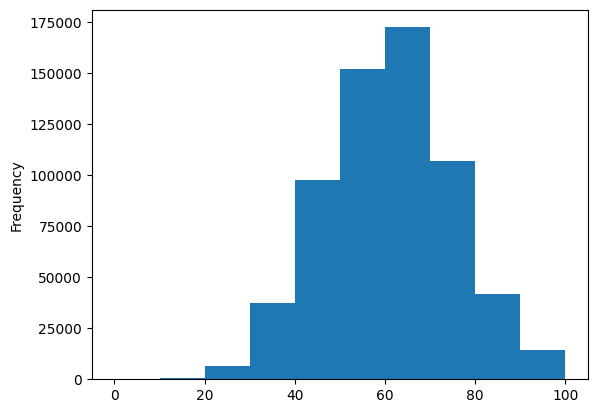

In [40]:
df['exam_score'].plot(kind='hist')

## Чанарын өгөгдөл засах

1. Тойм статистикаар үнэлэх
2. Өгөгдлийн хэдэн хувь дутуу байгааг тооцох (хэрэгцээт баганы өгөгдөл 5%-с дээш хоосон байвал асуудалтай)
3. .str.strip() ашиглан хажуугийн илүүц зайг хасах '    male ' -> 'male'
4. .value_counts() ашиглан категориудыг ажиглах
5. Bar эсвэл pie-аар дүрсэлж харах
6. Боломжтой бол бизнес мэдлэгтэй хүн эсвэл тухайн салбарын хүнээс лавлаж асуух
7. Текст нэгэн хэвийн бичиглэлтэй эсэхийг шалгах, текстийг засах
8. Тойм статистикийг дахин тооцоолох, дахин дүрсэлж харах
9. Хоосон утгыг нөхөхдөө (зарим тохиолдолд шууд хасаж болно)
    - Салбарын мэдлэг ашиглах
    - Моод ашиглах
    - Unknown гэдэг тусдаа категори шинээр нэмэх

In [41]:
df.describe(include='object')

,gender,course,internet_access,sleep_quality,study_method,facility_rating,exam_difficulty
count,367614,614318,614369,614120,614054,614076,614239
unique,17,7,2,9,10,7,3
top,male,b.tech,yes,poor,coaching,medium,moderate
freq,120185,127996,565047,206177,127087,206644,345105


In [42]:
df['sleep_quality'].value_counts()

,count
sleep_quality,
poor,206177
good,204594
average,196143
POOR,2120
GOOD,2063
AVERAGE,2001
GooD,347
gooD,339
gud,336


In [49]:
df['sleep_quality'] = df['sleep_quality'].str.lower()
df['sleep_quality'] = df['sleep_quality'].str.strip()

# хоосон зайг None болгох
df.loc[df['sleep_quality'] == '', 'sleep_quality'] = None

# ялгаатай бичиглэлийг засах
df.loc[df['sleep_quality'] == 'gud', 'sleep_quality'] = 'good'
df.loc[df['sleep_quality'].isin(['gud', 'guud', 'god']), 'sleep_quality'] = 'good'

# хоосон утгыг нөхөх
df.loc[df['sleep_quality'].isna(), 'sleep_quality'] = df['sleep_quality'].mode()[0]

<Axes: title={'center': 'Нойрны чанар'}, ylabel='count'>

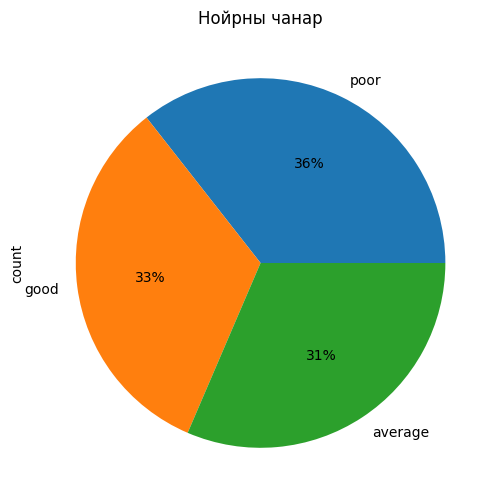

In [57]:
df['sleep_quality'].value_counts().plot(kind='pie', autopct='%1.0f%%', figsize=(6, 6), title='Нойрны чанар')

In [64]:
df['exam_difficulty'].value_counts()

# хоосон утгыг эрэмбийн дундаж ашиглан нөхөх
df.loc[df['exam_difficulty'].isna(), 'exam_difficulty'] = 'moderate'

In [63]:
# Бүх string-ыг strip хийж lower хийх

category_columns = df.select_dtypes(include='object').columns.to_list()

for col in category_columns:
  df[col] = df[col].str.strip().str.lower()

In [65]:
df.describe(include='all')

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
count,630000.000000,630000.000000,367614,614318,630000.000000,630000.000000,614369,630000.000000,630000,614054,614076,630000,630000.000000
unique,NaN,NaN,14,7,NaN,NaN,2,NaN,3,5,4,3,NaN
top,NaN,NaN,male,b.tech,NaN,NaN,yes,NaN,poor,coaching,medium,moderate,NaN
freq,NaN,NaN,121368,127996,NaN,NaN,565047,NaN,224177,128364,208737,360866,NaN
mean,314999.500000,20.561657,NaN,NaN,4.080467,72.290994,NaN,7.073387,NaN,NaN,NaN,NaN,60.402543
std,181865.479132,2.222596,NaN,NaN,2.446289,17.348453,NaN,1.722518,NaN,NaN,NaN,NaN,14.196977
min,0.000000,17.000000,NaN,NaN,0.080000,40.600000,NaN,4.100000,NaN,NaN,NaN,NaN,0.000000
25%,157499.750000,19.000000,NaN,NaN,2.040000,57.500000,NaN,5.600000,NaN,NaN,NaN,NaN,51.000000
50%,314999.500000,21.000000,NaN,NaN,4.030000,72.900000,NaN,7.100000,NaN,NaN,NaN,NaN,60.000000
75%,472499.250000,22.000000,NaN,NaN,6.050000,87.300000,NaN,8.600000,NaN,NaN,NaN,NaN,70.000000


In [66]:
# None мөрүүдийг хаях/drop хийх

df = df.dropna(subset=['internet_access', 'course', 'study_method'])

In [67]:
df.describe(include='all')

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
count,583880.000000,583880.000000,340698,583880,583880.000000,583880.000000,583880,583880.000000,583880,583880,569108,583880,583880.000000
unique,NaN,NaN,14,7,NaN,NaN,2,NaN,3,5,4,3,NaN
top,NaN,NaN,male,b.tech,NaN,NaN,yes,NaN,poor,coaching,medium,moderate,NaN
freq,NaN,NaN,112425,121524,NaN,NaN,536913,NaN,207785,122056,193551,334488,NaN
mean,314931.876658,20.560007,NaN,NaN,4.080356,72.295669,NaN,7.074191,NaN,NaN,NaN,NaN,60.407128
std,181866.494113,2.222513,NaN,NaN,2.446327,17.345965,NaN,1.722292,NaN,NaN,NaN,NaN,14.199226
min,1.000000,17.000000,NaN,NaN,0.080000,40.600000,NaN,4.100000,NaN,NaN,NaN,NaN,0.000000
25%,157398.750000,19.000000,NaN,NaN,2.040000,57.500000,NaN,5.600000,NaN,NaN,NaN,NaN,51.000000
50%,314915.500000,21.000000,NaN,NaN,4.030000,72.900000,NaN,7.100000,NaN,NaN,NaN,NaN,60.000000
75%,472417.250000,22.000000,NaN,NaN,6.050000,87.300000,NaN,8.600000,NaN,NaN,NaN,NaN,70.000000


In [125]:
clean_df = df[['age', 'course', 'study_hours', 'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality', 'study_method', 'exam_difficulty', 'exam_score']]

In [126]:
clean_df.head()

,age,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,exam_difficulty,exam_score
1,18.0,diploma,4.95,94.8,yes,4.7,poor,self-study,moderate,66.0
2,20.0,b.sc,4.68,92.6,yes,5.8,poor,coaching,moderate,75.0
3,19.0,b.sc,2.00,49.5,yes,8.3,average,group study,moderate,60.0
4,23.0,bca,7.65,86.9,yes,9.6,good,self-study,easy,87.0
5,24.0,b.com,5.04,85.1,yes,9.4,average,online videos,moderate,73.0


In [127]:
# descriptive statistic aa turul bureer harah

clean_df.groupby(['course'])['age'].describe()

,count,mean,std,min,25%,50%,75%,max
course,,,,,,,,
b.com,102906.0,20.562494,2.223533,17.0,19.0,21.0,22.0,24.0
b.sc,103377.0,20.569614,2.219314,17.0,19.0,21.0,22.0,24.0
b.tech,121524.0,20.569229,2.233814,17.0,19.0,21.0,23.0,24.0
ba,57480.0,20.526670,2.227587,17.0,19.0,21.0,22.0,24.0
bba,70128.0,20.555941,2.224718,17.0,19.0,21.0,22.0,24.0
bca,82245.0,20.560946,2.220669,17.0,19.0,21.0,22.0,24.0
diploma,46220.0,20.554695,2.190710,17.0,19.0,21.0,22.0,24.0


In [128]:
#def attendance(num):
#  if num > 80:
#    return 'attendance good'
#  elif num > 50:
#    return 'attendance average'
#  else:
#    return 'attendance low'

#clean_df['attendance_category'] = clean_df['class_attendance'].apply(attendance)

### Correlation

In [129]:
# pearson buyu default shuluun hamaaral
# spearman murui hamaaral

clean_df[['age', 'study_hours', 'class_attendance', 'sleep_hours', 'exam_score']].corr()

,age,study_hours,class_attendance,sleep_hours,exam_score
age,1.000000,0.006999,0.005630,0.005045,0.010272
study_hours,0.006999,1.000000,0.079186,0.038502,0.585170
class_attendance,0.005630,0.079186,1.000000,0.028415,0.498179
sleep_hours,0.005045,0.038502,0.028415,1.000000,0.317129
exam_score,0.010272,0.585170,0.498179,0.317129,1.000000


### Feature Engineering

In [130]:
clean_df.describe()

,age,study_hours,class_attendance,sleep_hours,exam_score
count,583880.000000,583880.000000,583880.000000,583880.000000,583880.000000
mean,20.560007,4.080356,72.295669,7.074191,60.407128
std,2.222513,2.446327,17.345965,1.722292,14.199226
min,17.000000,0.080000,40.600000,4.100000,0.000000
25%,19.000000,2.040000,57.500000,5.600000,51.000000
50%,21.000000,4.030000,72.900000,7.100000,60.000000
75%,22.000000,6.050000,87.300000,8.600000,70.000000
max,24.000000,11.865000,100.000000,9.900000,100.000000


In [131]:
# Шинэ feature үүсгэх

clean_df["low_effort"] = ((clean_df["class_attendance"] < 60) & (clean_df['study_hours'] < 2)).astype(int)


/tmp/ipython-input-1987654978.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df["low_effort"] = ((clean_df["class_attendance"] < 60) & (clean_df['study_hours'] < 2)).astype(int)


In [132]:
clean_df.head()

,age,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,exam_difficulty,exam_score,low_effort
1,18.0,diploma,4.95,94.8,yes,4.7,poor,self-study,moderate,66.0,0
2,20.0,b.sc,4.68,92.6,yes,5.8,poor,coaching,moderate,75.0,0
3,19.0,b.sc,2.00,49.5,yes,8.3,average,group study,moderate,60.0,0
4,23.0,bca,7.65,86.9,yes,9.6,good,self-study,easy,87.0,0
5,24.0,b.com,5.04,85.1,yes,9.4,average,online videos,moderate,73.0,0


In [133]:
# эрэмбийн категори -> тоон

sleep_quality_map = {
    "poor": -2,
    "average": 0,
    "good": 2
}

exam_difficulty_map = {
    "easy": 3,
    "moderate": 0,
    "hard": -3
}

internet_access_map = {
    "no": 0,
    "yes": 1
}

clean_df['sleep_quality_int'] = clean_df['sleep_quality'].map(sleep_quality_map)
clean_df['exam_difficulty_int'] = clean_df['exam_difficulty'].map(exam_difficulty_map)
clean_df['internet_access_int'] = clean_df['internet_access'].map(internet_access_map)

/tmp/ipython-input-1723122241.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['sleep_quality_int'] = clean_df['sleep_quality'].map(sleep_quality_map)


In [134]:
clean_df.head()

,age,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,exam_difficulty,exam_score,low_effort,sleep_quality_int,exam_difficulty_int,internet_access_int
1,18.0,diploma,4.95,94.8,yes,4.7,poor,self-study,moderate,66.0,0,-2,0,1
2,20.0,b.sc,4.68,92.6,yes,5.8,poor,coaching,moderate,75.0,0,-2,0,1
3,19.0,b.sc,2.00,49.5,yes,8.3,average,group study,moderate,60.0,0,0,0,1
4,23.0,bca,7.65,86.9,yes,9.6,good,self-study,easy,87.0,0,2,3,1
5,24.0,b.com,5.04,85.1,yes,9.4,average,online videos,moderate,73.0,0,0,0,1


In [135]:
## dummy variables (one-hot encoding)

clean_df = pd.get_dummies(clean_df, columns=['course'], drop_first=True, dtype=int)
clean_df = pd.get_dummies(clean_df, columns=['study_method'], drop_first=True, dtype=int)

In [136]:
clean_df.drop(columns=['internet_access', 'sleep_quality', 'exam_difficulty'], inplace=True)

In [137]:
clean_df.columns

Index(['age', 'study_hours', 'class_attendance', 'sleep_hours', 'exam_score',
       'low_effort', 'sleep_quality_int', 'exam_difficulty_int',
       'internet_access_int', 'course_b.sc', 'course_b.tech', 'course_ba',
       'course_bba', 'course_bca', 'course_diploma',
       'study_method_group study', 'study_method_mixed',
       'study_method_online videos', 'study_method_self-study'],
      dtype='object')

### Regression

In [138]:
import statsmodels.api as sm

X = clean_df.drop(columns=['exam_score'])
y = clean_df['exam_score']


X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

In [139]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             exam_score   R-squared:                       0.641
Model:                            OLS   Adj. R-squared:                  0.641
Method:                 Least Squares   F-statistic:                 5.793e+04
Date:                Wed, 28 Jan 2026   Prob (F-statistic):               0.00
Time:                        07:47:30   Log-Likelihood:            -2.0785e+06
No. Observations:              583880   AIC:                         4.157e+06
Df Residuals:                  583861   BIC:                         4.157e+06
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

### Үр дүн тайлбар

Шалгалтын оноонд нөлөөлөх эерэг хүчин зүйлс:

- study_hours
- sleep_hours
- internet_access
- class_attendance

Сөрөг хүчин зүйлс:

- low_effort (low attendance & low study hours)
- self-study / group study

Чухал биш:

- course type
- exam_difficulty
- mixed study method

## Linear Regression Model

In [141]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Дээрх санг ашиглана
X = clean_df.drop(columns=['exam_score'])
y = clean_df['exam_score']


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# сургалт болон тестийн датад хуваана
################################       WARNING        ################################
# загвар сургах үед сургалтын дата болон тестийн датаны хоосон утгыг нөхөхдөө тусад нь хийх хэрэгтэй
# clean_df-г шууд ашигласнаар бага зэрэг data leakage үүсэж байна. (Хангалттай том датасет ашиглаж
# буй учир median ойролцоо гарах ч best practice бол тусад нь датагаа нөхөх)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Data leakage бага зэрэг үүссэн
r2 = r2_score(y_test, y_pred)
print("R2:", r2)

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

R2: 0.6417979833892555
MSE: 72.27512132547359
